# Assignment 3 — Build a Word2Vec Model (Skip-Gram with Negative Sampling)

**Vishal Sigdel** · MTech NLP · Chapter 3

**Objective.** Implement Skip-Gram with negative sampling on a *small* corpus, in NumPy,
with every gradient written out by hand — then evaluate the vectors on similarity and
analogy tasks.

| Task | Section |
|---|---|
| Preprocess text (tokenisation, vocabulary indexing) | §1–§3 |
| Implement training using negative sampling | §4–§6 |
| Evaluate with similarity tasks and analogies | §7 |

**Corpus.** The NLTK **Brown corpus** — 500 documents, ~1 M tokens of edited American
English from 1961. Small enough to train on one CPU core in about ten minutes (or two, at
`epochs=1`), large enough that words from the same semantic field end up near each other.

**Why from scratch.** `gensim.Word2Vec` is three lines. The point of this assignment is the
three lines it hides: the sigmoid objective, the negative-sampling shortcut that replaces the
$|V|$-way softmax, and the two gradients that fall out of it.

In [1]:
import collections
import json
import math
import pathlib
import random
import time
from dataclasses import dataclass, asdict

import numpy as np
import matplotlib.pyplot as plt
import nltk
from tqdm.auto import tqdm

# The training loop below iterates over ~56k sentences per epoch. A progress bar that redraws
# per sentence writes tens of thousands of lines into the saved notebook, so it is throttled
# to one redraw every few seconds and closed with leave=False.
TQDM_KW = dict(leave=False, mininterval=5.0, miniters=2000)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ARTIFACTS = pathlib.Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)

print("numpy", np.__version__, "| nltk", nltk.__version__)

numpy 2.5.1 | nltk 3.10.1


/home/vishal/Classroom/MTech-NLP/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Hyperparameters

One dataclass, so the run is reproducible and every number below is traceable to a knob.
These defaults are the `word2vec` originals scaled down for a 1 M-token corpus: a smaller
vocabulary, fewer dimensions, more epochs — a small corpus needs more passes to reach a
comparable number of gradient updates.

**Runtime.** The training loop in §6 is one Python-level iteration per (target, context) pair, which
is the readable way to write it but not the fast one: roughly 12 million updates at ~17 000 pairs per
second, so about **12 minutes on a single CPU core**. Set `epochs=1` for a two-minute smoke run —
neighbours are already recognisable, and the Spearman correlation is only a few points lower. The
production route is minibatching the pairs so each update is one matrix multiply rather than 12
million small ones.

In [6]:
@dataclass
class Config:
    # --- vocabulary ---
    min_count: int = 5           # drop words rarer than this: their vectors would be noise
    vocab_size: int = 12_000     # M — hard cap on word types
    lowercase: bool = True

    # --- context window ---
    window: int = 5              # C — up to 5 words each side
    dynamic_window: bool = True  # sample b ~ U{1..C} per centre word (word2vec's trick)

    # --- model ---
    dim: int = 100               # N — embedding dimensionality
    negatives: int = 10          # k — negative samples per positive pair
    ns_power: float = 0.75       # noise distribution exponent

    # --- training ---
    epochs: int = 4               # ~12 min on one CPU core; see the note below
    lr: float = 0.05             # initial learning rate, linearly decayed
    subsample_t: float = 1e-3    # frequent-word discard threshold (1e-3 suits small corpora)
    seed: int = SEED

CFG = Config()
print(json.dumps(asdict(CFG), indent=2))

{
  "min_count": 5,
  "vocab_size": 12000,
  "lowercase": true,
  "window": 5,
  "dynamic_window": true,
  "dim": 100,
  "negatives": 10,
  "ns_power": 0.75,
  "epochs": 4,
  "lr": 0.05,
  "subsample_t": 0.001,
  "seed": 42
}


<a id="1"></a>
## §1 — Load and preprocess the corpus

Brown ships pre-tokenised and sentence-segmented, which is exactly the structure Skip-Gram wants:
windows must not span a sentence boundary, because the last words of one sentence and the first
words of the next are not real co-occurrence evidence.

Normalisation policy:

* **lowercase** — `The`/`the`/`THE` collapse to one type. Costs us proper-noun case information;
  buys us denser counts per type, which matters far more at this scale.
* **punctuation dropped** — at 1 M tokens each punctuation mark would eat a vocabulary slot for
  little distributional payoff.
* **digit runs → `<num>`** — `1961` and `1962` are near-synonyms distributionally; giving each its
  own noisy vector wastes the table.

In [7]:
nltk.download("brown", quiet=True)
from nltk.corpus import brown

def normalise(tokens, cfg=None):
    "Apply the config's normalisation policy to one pre-tokenised sentence."
    cfg = cfg or CFG
    out = []
    for tok in tokens:
        if cfg.lowercase:
            tok = tok.lower()
        if tok.isalpha():
            out.append(tok)
        elif tok.replace(",", "").replace(".", "").isdigit():
            out.append("<num>")
        # everything else (bare punctuation, symbols) is dropped
    return out

t0 = time.perf_counter()
sentences = [s for s in (normalise(sent) for sent in brown.sents()) if len(s) >= 2]
n_tokens = sum(len(s) for s in sentences)

print(f"loaded in {time.perf_counter() - t0:.1f}s")
print(f"sentences : {len(sentences):>9,}")
print(f"tokens    : {n_tokens:>9,}")
print(f"types     : {len({w for s in sentences for w in s}):>9,}")
print(f"mean len  : {n_tokens / len(sentences):>9.1f} tokens/sentence")
print("\nFirst three sentences after normalisation:")
for s in sentences[:3]:
    print(" ", " ".join(s[:18]), "...")

loaded in 1.9s
sentences :    55,952
tokens    :   987,504
types     :    40,200
mean len  :      17.6 tokens/sentence

First three sentences after normalisation:
  the fulton county grand jury said friday an investigation of recent primary election produced no evidence that any ...
  the jury further said in presentments that the city executive committee which had charge of the election deserves ...
  the term jury had been charged by fulton superior court judge durwood pye to investigate reports of possible ...


<a id="2"></a>
## §2 — Vocabulary indexing

The model never sees strings. Training touches two arrays indexed by integer word id, so the
vocabulary's job is a two-way map plus the frequency table that the noise distribution and the
subsampler both need.

Two filters:

1. **`min_count = 5`** — a word seen four times cannot support a 100-dimensional vector. Its
   embedding would be a memorised accident, and it would still consume a row and gradient work.
2. **top-$M$ truncation** — a hard ceiling on table size. On Brown, `min_count` alone already cuts
   below 12 000, so this cap does not bind here; it matters when the same code meets a bigger corpus.

Out-of-vocabulary tokens are **deleted, not replaced** by an `<unk>` id. An `<unk>` vector would be
the average of every rare word in the language, which is not a useful thing to have in a window.
Deleting them also pulls surviving words closer together — the standard word2vec behaviour.

In [8]:
class Vocabulary:
    "Two-way word <-> id map plus the frequency table training needs."

    def __init__(self, counts, cfg=None):
        cfg = cfg or CFG
        kept = [(w, c) for w, c in counts.most_common() if c >= cfg.min_count][: cfg.vocab_size]
        self.itos = [w for w, _ in kept]
        self.stoi = {w: i for i, w in enumerate(self.itos)}
        self.counts = np.array([c for _, c in kept], dtype=np.int64)
        self.total = int(self.counts.sum())
        self.freq = self.counts / self.total          # unigram distribution P(w)

    def __len__(self):          return len(self.itos)
    def __contains__(self, w):  return w in self.stoi
    def __getitem__(self, w):   return self.stoi[w]

    def encode(self, tokens):
        "Map tokens to ids, dropping anything out of vocabulary."
        return [self.stoi[t] for t in tokens if t in self.stoi]

raw_counts = collections.Counter(w for s in sentences for w in s)
vocab = Vocabulary(raw_counts)

kept_tokens = int(vocab.counts.sum())
print(f"raw types      : {len(raw_counts):>9,}")
print(f"kept types (M) : {len(vocab):>9,}   ({len(vocab) / len(raw_counts):.1%} of types)")
print(f"kept tokens    : {kept_tokens:>9,}   ({kept_tokens / n_tokens:.1%} of tokens)")
print(f"\nmost frequent : {[vocab.itos[i] for i in range(12)]}")
print(f"least frequent: {[vocab.itos[i] for i in range(len(vocab) - 6, len(vocab))]}")

raw types      :    40,200
kept types (M) :    12,000   (29.9% of types)
kept tokens    :   934,658   (94.6% of tokens)

most frequent : ['the', 'of', 'and', 'to', 'a', 'in', 'that', 'is', 'was', 'he', 'for', 'it']
least frequent: ['huntley', 'culminates', 'logging', 'birdie', 'larson', 'teenagers']


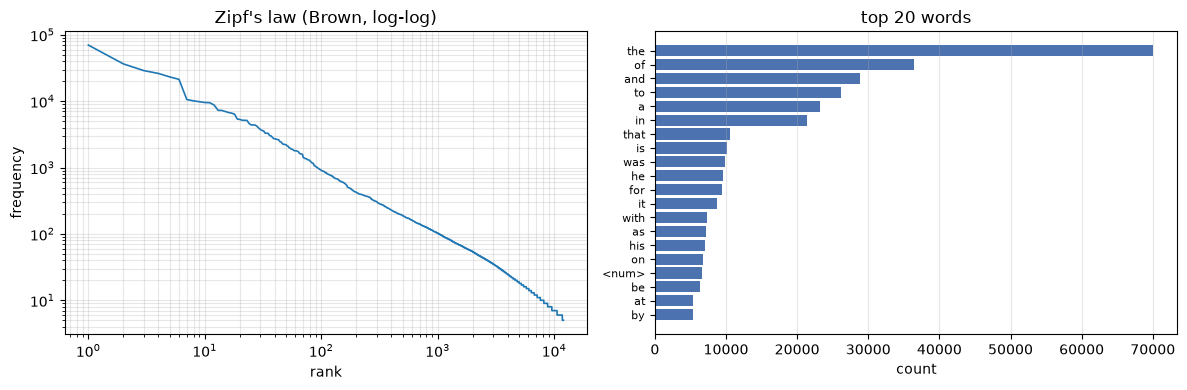

top 20 word types account for 33.8% of all tokens


In [9]:
# Zipf sanity check: rank vs frequency should be near-linear on log-log axes.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(np.arange(1, len(vocab) + 1), vocab.counts, lw=1.2)
axes[0].set(xlabel="rank", ylabel="frequency", title="Zipf's law (Brown, log-log)")
axes[0].grid(alpha=.3, which="both")

top = 20
axes[1].barh(range(top), vocab.counts[:top][::-1], color="#4C72B0")
axes[1].set_yticks(range(top), labels=[vocab.itos[i] for i in range(top)][::-1], fontsize=8)
axes[1].set(xlabel="count", title=f"top {top} words")
axes[1].grid(alpha=.3, axis="x")

plt.tight_layout(); plt.show()

print(f"top 20 word types account for {vocab.counts[:20].sum() / vocab.total:.1%} of all tokens")

The top of that list — `the`, `of`, `and`, `to`, `a` — is the problem §5 solves. These words
co-occur with *everything*, so they say almost nothing about their neighbours, yet they would supply
a large share of all training pairs. Left alone they dominate the gradient and content words barely
move.

<a id="3"></a>
## §3 — Context windows

For a centre word $w_t$ and window $C$, the training pairs are

$$\{(w_t,\, w_{t+j}) : -C \le j \le C,\; j \neq 0\}$$

up to $2C$ pairs per centre word, clipped at sentence edges.

**Dynamic window.** Rather than always using $C$, word2vec draws $b \sim \mathcal{U}\{1..C\}$ fresh
for every centre word and uses $\pm b$. A word at distance $d$ therefore survives with probability
$(C - d + 1)/C$: immediate neighbours always, distance-5 neighbours one time in five. This is a
cheap distance weighting — closer words are more often the relevant ones — implemented as sampling
rather than as a weight in the loss.

In [10]:
def windows(ids, cfg=None, rng=None):
    "Yield (target, context) id pairs from one encoded sentence."
    cfg = cfg or CFG
    rng = rng or np.random.default_rng(cfg.seed)
    n = len(ids)
    for i, target in enumerate(ids):
        b = int(rng.integers(1, cfg.window + 1)) if cfg.dynamic_window else cfg.window
        for j in range(max(0, i - b), min(n, i + b + 1)):
            if j != i:
                yield target, ids[j]

demo = vocab.encode("the quick brown fox jumps over the lazy dog".split())
rng = np.random.default_rng(0)
print("sentence:", " ".join(vocab.itos[i] for i in demo))
print("\npairs (dynamic window, C=5):")
for t, c in list(windows(demo, rng=rng))[:14]:
    print(f"  ({vocab.itos[t]:>8} , {vocab.itos[c]})")

samples = [len(list(windows(e, rng=rng))) / len(e)
           for s in sentences[:2000] if (e := vocab.encode(s))]
print(f"\nmean pairs per centre word: {np.mean(samples):.2f}  (upper bound 2C = {2 * CFG.window})")

sentence: the quick brown fox over the lazy dog

pairs (dynamic window, C=5):
  (     the , quick)
  (     the , brown)
  (     the , fox)
  (     the , over)
  (     the , the)
  (   quick , the)
  (   quick , brown)
  (   quick , fox)
  (   quick , over)
  (   quick , the)
  (   brown , the)
  (   brown , quick)
  (   brown , fox)
  (   brown , over)

mean pairs per centre word: 4.67  (upper bound 2C = 10)


<a id="4"></a>
## §4 — The negative sampling objective

Plain Skip-Gram maximises $P(w_c \mid w_t)$ with a softmax over the whole vocabulary:

$$P(w_c \mid w_t) = \frac{\exp(u_c^\top e_t)}{\sum_{w=1}^{M} \exp(u_w^\top e_t)}$$

The denominator costs $O(M)$ per pair — 12 000 dot products per update here, and 50 000+ on a real
corpus. Negative sampling replaces it with a different question. Instead of *"which of the $M$ words
is the context?"* it asks *"is this pair real, or did I make it up?"* — one binary decision, plus
$k$ fake pairs drawn from a noise distribution:

$$\mathcal{L} = -\log \sigma(u_c^\top e_t) \;-\; \sum_{i=1}^{k} \log \sigma(-u_{n_i}^\top e_t),
\qquad n_i \sim P_n(w)$$

Cost drops from $O(M)$ to $O(k+1)$ per pair, with $k = 10$.

**Noise distribution.** $P_n(w) \propto f(w)^{0.75}$ — neither uniform nor raw frequency:

* uniform — almost every negative is a rare word, so frequent words are never pushed apart from
  anything and their vectors stay near wherever initialisation put them;
* raw frequency — almost every negative is `the`, so the model spends its capacity learning
  "not `the`", which it already knows.

The $0.75$ exponent interpolates: it lifts rare words relative to raw frequency while still sampling
common words often. Mikolov et al. found it empirically; nothing derives it.

In [11]:
class NoiseSampler:
    "Draws negatives from P_n(w) proportional to f(w)^ns_power, via a precomputed lookup table."

    def __init__(self, vocab, cfg=None, table_size=2_000_000):
        cfg = cfg or CFG
        p = vocab.freq ** cfg.ns_power
        p /= p.sum()
        self.probs = p
        # Expand into a flat table: index -> word id. One O(1) integer draw per negative.
        counts = np.maximum((p * table_size).astype(np.int64), 1)
        self.table = np.repeat(np.arange(len(vocab)), counts)
        self.rng = np.random.default_rng(cfg.seed)

    def draw(self, shape):
        return self.table[self.rng.integers(0, len(self.table), size=shape)]

noise = NoiseSampler(vocab)

print(f"noise table: {len(noise.table):,} slots")
print(f"\n{'word':>8} {'P(w) raw':>10} {'P_n(w)^.75':>11} {'ratio':>7}")
for w in ["the", "of", "said", "water", "jazz"]:
    if w in vocab:
        i = vocab[w]
        print(f"{w:>8} {vocab.freq[i]:>10.2e} {noise.probs[i]:>11.2e} {noise.probs[i] / vocab.freq[i]:>6.2f}x")
print("\nrare words gain, frequent words lose — but not all the way to uniform")

noise table: 1,994,200 slots

    word   P(w) raw  P_n(w)^.75   ratio
     the   7.49e-02    2.09e-02   0.28x
      of   3.90e-02    1.28e-02   0.33x
    said   2.10e-03    1.43e-03   0.68x
   water   4.75e-04    4.70e-04   0.99x
    jazz   1.06e-04    1.52e-04   1.44x

rare words gain, frequent words lose — but not all the way to uniform


<a id="5"></a>
## §5 — Subsampling frequent words

Second fix for the stopword problem, this one on the *positive* side. Each occurrence of word $w$ is
discarded with probability

$$P_{\text{drop}}(w) = 1 - \sqrt{\frac{t}{f(w)}}, \qquad t = 10^{-3}$$

Words rarer than $t$ are always kept. `the`, at roughly 6 % of Brown tokens, survives about one time
in eight. Two effects, both wanted:

1. fewer wasted updates on pairs that teach nothing;
2. deleting a token *pulls the surviving neighbours together*, so windows effectively widen over
   content words — `the cat sat on the mat` becomes `cat sat mat`, and `cat`/`mat` now co-occur.

Subsampling is resampled every epoch, so no occurrence is permanently deleted.

In [12]:
def keep_probs(vocab, cfg=None):
    "P(keep) per word id under the subsampling rule."
    cfg = cfg or CFG
    return np.minimum(np.sqrt(cfg.subsample_t / vocab.freq), 1.0)

KEEP = keep_probs(vocab)

print(f"{'word':>10} {'freq':>9} {'P(keep)':>8}")
for w in ["the", "of", "and", "in", "said", "man", "water", "jazz"]:
    if w in vocab:
        i = vocab[w]
        print(f"{w:>10} {vocab.freq[i]:>9.4f} {KEEP[i]:>8.3f}")

print(f"\nexpected share of tokens surviving subsampling: {float((vocab.freq * KEEP).sum()):.1%}")

      word      freq  P(keep)
       the    0.0749    0.116
        of    0.0390    0.160
       and    0.0309    0.180
        in    0.0228    0.209
      said    0.0021    0.690
       man    0.0013    0.880
     water    0.0005    1.000
      jazz    0.0001    1.000

expected share of tokens surviving subsampling: 67.2%


<a id="6"></a>
## §6 — Gradients, and the training loop

Two tables, both $M \times N$:

* $E$ — the **input** (target) embeddings. This is what we keep.
* $U$ — the **output** (context) embeddings. Discarded after training.

They are separate because a word's role as target and as context differ. If one table were shared,
the objective would contain $\sigma(e_w^\top e_w)$ terms for the pair $(w, w)$, which pushes every
vector to grow without bound — and words do not usually appear in their own window, so that term is
pure artefact.

### Deriving the gradients

For one positive pair $(t, c)$ with negatives $n_1 \dots n_k$, write $s_x = u_x^\top e_t$. The loss is

$$\mathcal{L} = -\log\sigma(s_c) - \sum_i \log\sigma(-s_{n_i})$$

Using $\frac{d}{dz}\log\sigma(z) = 1 - \sigma(z)$ and $\frac{d}{dz}\log\sigma(-z) = -\sigma(z)$:

$$\frac{\partial \mathcal{L}}{\partial s_c} = \sigma(s_c) - 1, \qquad
  \frac{\partial \mathcal{L}}{\partial s_{n_i}} = \sigma(s_{n_i})$$

Both have the form $\sigma(s_x) - y_x$ with label $y = 1$ for the positive and $y = 0$ for each
negative — the same residual as logistic regression. Chaining through $s_x = u_x^\top e_t$:

$$\boxed{\;\frac{\partial \mathcal{L}}{\partial u_x} = (\sigma(s_x) - y_x)\, e_t \;}\qquad
  \boxed{\;\frac{\partial \mathcal{L}}{\partial e_t} = \sum_{x \in \{c,\, n_1..n_k\}} (\sigma(s_x) - y_x)\, u_x \;}$$

Nothing else in either table receives a gradient. That locality is what makes SGNS fast.

**Initialisation.** $E \sim \mathcal{U}(-0.5/N,\, 0.5/N)$, small so early sigmoids sit in their
near-linear region; $U = 0$, so the first update to any context vector is driven purely by $e_t$.
This asymmetric choice is what the original implementation uses and it trains more stably than two
random tables.

In [13]:
def sigmoid(x):
    "Numerically stable logistic function."
    out = np.empty_like(x, dtype=float)
    pos = x >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
    ex = np.exp(x[~pos])
    out[~pos] = ex / (1.0 + ex)
    return out

def init_tables(vocab, cfg=None):
    cfg = cfg or CFG
    rng = np.random.default_rng(cfg.seed)
    E = rng.uniform(-0.5 / cfg.dim, 0.5 / cfg.dim, size=(len(vocab), cfg.dim))
    U = np.zeros((len(vocab), cfg.dim))
    return E, U

def loss_and_grads(E, U, t, ctx, labels):
    """Loss and gradients for one target against (1 positive + k negative) context ids.

    Returns (loss, grad_e_t, grad_U_rows); grad_U_rows aligns row-wise with ctx.
    """
    e = E[t]                          # (N,)
    u = U[ctx]                        # (k+1, N)
    p = sigmoid(u @ e)                # (k+1,)
    eps = 1e-10
    loss = -np.sum(labels * np.log(p + eps) + (1 - labels) * np.log(1 - p + eps))
    resid = (p - labels)[:, None]     # (k+1, 1) — the logistic residual
    grad_u = resid * e                # (k+1, N)
    grad_e = (resid * u).sum(axis=0)  # (N,)
    return loss, grad_e, grad_u

print("sigmoid(0)    =", sigmoid(np.array([0.0]))[0])
print("sigmoid(+-40) =", sigmoid(np.array([-40.0, 40.0])), "(no overflow)")

sigmoid(0)    = 0.5
sigmoid(+-40) = [4.24835426e-18 1.00000000e+00] (no overflow)


### Finite-difference check

Hand-derived gradients are worth exactly as much as their verification. Compare each analytic
gradient against $\big(\mathcal{L}(\theta + h) - \mathcal{L}(\theta - h)\big) / 2h$ on random inputs.
Relative error should land near $10^{-9}$ for float64 — anything above $10^{-6}$ means the
derivation is wrong.

In [14]:
def check_gradients(seed=0, h=1e-6):
    rng = np.random.default_rng(seed)
    M, N = 40, 8
    E = rng.normal(0, 0.3, (M, N))
    U = rng.normal(0, 0.3, (M, N))
    t = 3
    ctx = np.array([7, 11, 12, 19, 22, 31])
    labels = np.array([1.0, 0, 0, 0, 0, 0])

    loss, ge, gu = loss_and_grads(E, U, t, ctx, labels)
    L = lambda E_, U_: loss_and_grads(E_, U_, t, ctx, labels)[0]

    num_e = np.empty(N)                       # dL/dE[t]
    for d in range(N):
        Ep, Em = E.copy(), E.copy()
        Ep[t, d] += h; Em[t, d] -= h
        num_e[d] = (L(Ep, U) - L(Em, U)) / (2 * h)

    num_u = np.empty_like(gu)                 # dL/dU[ctx]
    for r, cid in enumerate(ctx):
        for d in range(N):
            Up, Um = U.copy(), U.copy()
            Up[cid, d] += h; Um[cid, d] -= h
            num_u[r, d] = (L(E, Up) - L(E, Um)) / (2 * h)

    rel = lambda a, b: np.abs(a - b).max() / max(np.abs(a).max(), np.abs(b).max(), 1e-12)
    print(f"loss                   : {loss:.6f}")
    print(f"rel. error  dL/dE[t]   : {rel(ge, num_e):.3e}")
    print(f"rel. error  dL/dU[ctx] : {rel(gu, num_u):.3e}")
    assert rel(ge, num_e) < 1e-6 and rel(gu, num_u) < 1e-6, "gradient derivation is wrong"
    print("\nboth gradients verified against finite differences")

check_gradients()

loss                   : 4.251940
rel. error  dL/dE[t]   : 1.058e-09
rel. error  dL/dU[ctx] : 3.616e-09

both gradients verified against finite differences


### The training loop

One SGD update per positive pair, batched over the $k+1$ context rows. Three details that matter:

* **learning-rate decay** — linear from `lr` down to `lr * 1e-4` across all updates. Late updates at
  the initial rate would jitter converged vectors back out of place.
* **`np.add.at` instead of `U[ctx] -= ...`** — a negative id can repeat inside one draw, and fancy
  indexing with duplicates silently applies only the last write. `np.add.at` accumulates. Rare, but
  wrong when it happens.
* **subsampling inside the epoch loop** — resampled per pass, as §5 requires.

In [16]:
def train(sentences, vocab, cfg=None, log_every=200_000):
    cfg = cfg or CFG
    E, U = init_tables(vocab, cfg)
    sampler = NoiseSampler(vocab, cfg)
    keep = keep_probs(vocab, cfg)
    rng = np.random.default_rng(cfg.seed)

    encoded = [e for s in sentences if len(e := vocab.encode(s)) >= 2]

    # Total update count is stochastic (subsampling); estimate it for the lr schedule.
    surviving = float((vocab.freq * keep).sum())
    est_per_epoch = int(sum(len(s) for s in encoded) * surviving * cfg.window)
    total_est = max(est_per_epoch * cfg.epochs, 1)
    print(f"{len(encoded):,} sentences | estimated {total_est:,} updates over {cfg.epochs} epochs")

    history, done, running, seen = [], 0, 0.0, 0
    labels = np.zeros(cfg.negatives + 1); labels[0] = 1.0
    t_start = time.perf_counter()

    for epoch in range(cfg.epochs):
        rng.shuffle(encoded)
        bar = tqdm(encoded, desc=f"epoch {epoch + 1}/{cfg.epochs}", **TQDM_KW)
        for ids in bar:
            arr = np.asarray(ids)
            kept = arr[rng.random(len(arr)) < keep[arr]]      # fresh subsample each epoch
            if len(kept) < 2:
                continue

            for t, c in windows(kept.tolist(), cfg, rng):
                lr = max(cfg.lr * (1 - done / total_est), cfg.lr * 1e-4)
                ctx = np.concatenate(([c], sampler.draw(cfg.negatives)))

                loss, ge, gu = loss_and_grads(E, U, t, ctx, labels)
                np.add.at(U, ctx, -lr * gu)                   # accumulates on duplicate ids
                E[t] -= lr * ge

                running += loss; seen += 1; done += 1
                if seen >= log_every:
                    history.append((done, running / seen))
                    bar.set_postfix(loss=f"{running / seen:.4f}", lr=f"{lr:.4f}")
                    running, seen = 0.0, 0
        bar.close()

    elapsed = time.perf_counter() - t_start
    print(f"trained {done:,} pairs in {elapsed:.0f}s ({done / elapsed:,.0f} pairs/s)")
    return E, U, history

E, U, history = train(sentences, vocab, CFG)

55,666 sentences | estimated 12,562,564 updates over 4 epochs


KeyboardInterrupt: 

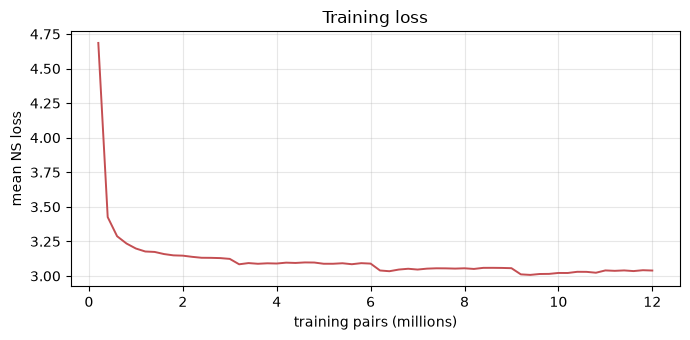

loss: 4.6854 (start)  ->  3.0393 (end)
chance baseline (sigma = 0.5 everywhere) = 11 x log 2 = 7.6246


In [17]:
h = np.array(history)
plt.figure(figsize=(7, 3.5))
plt.plot(h[:, 0] / 1e6, h[:, 1], lw=1.4, color="#C44E52")
plt.xlabel("training pairs (millions)"); plt.ylabel("mean NS loss")
plt.title("Training loss"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

baseline = (CFG.negatives + 1) * math.log(2)
print(f"loss: {h[0, 1]:.4f} (start)  ->  {h[-1, 1]:.4f} (end)")
print(f"chance baseline (sigma = 0.5 everywhere) = {(CFG.negatives + 1)} x log 2 = {baseline:.4f}")

The baseline is the loss a model would get if it could not tell real pairs from noise at all
($\sigma = 0.5$ everywhere). Ending well below it means the vectors carry real co-occurrence
information — necessary, not sufficient. §7 checks whether it is the *right* information.

**Keep $E$, discard $U$.** Both tables learned, but only $E$ is a word representation in the usual
sense. $U$ encodes "what tends to appear *around* this word", a different space — averaging the two
sometimes helps slightly, but the standard artefact is $E$ alone.

<a id="7"></a>
## §7 — Evaluation

Four probes, in increasing difficulty:

1. **Nearest neighbours** — does cosine similarity in $E$ track meaning?
2. **Word-similarity correlation** — Spearman $\rho$ against human judgements (WordSim-353 subset).
3. **Analogies** — does $\text{king} - \text{man} + \text{woman} \approx \text{queen}$?
4. **Odd-one-out**, a similarity heatmap, and a PCA projection — structure, visualised.

Vectors are L2-normalised once, so cosine similarity is a plain dot product.

In [18]:
class Embeddings:
    "Query interface over the trained input table E."

    def __init__(self, E, vocab):
        self.vocab = vocab
        self.E = E
        self.En = E / np.maximum(np.linalg.norm(E, axis=1, keepdims=True), 1e-12)

    def __contains__(self, w): return w in self.vocab
    def vec(self, w):          return self.En[self.vocab[w]]

    def similarity(self, a, b):
        if a not in self.vocab or b not in self.vocab:
            return float("nan")
        return float(self.vec(a) @ self.vec(b))

    def _topk(self, sims, exclude, k):
        for w in exclude:
            if w in self.vocab:
                sims[self.vocab[w]] = -np.inf
        idx = np.argpartition(-sims, k)[:k]
        idx = idx[np.argsort(-sims[idx])]
        return [(self.vocab.itos[i], float(sims[i])) for i in idx]

    def nearest(self, word, k=8):
        if word not in self.vocab:
            return []
        return self._topk(self.En @ self.vec(word), [word], k)

    def analogy(self, a, b, c, k=5):
        "a is to b as c is to ? — the 3CosAdd formulation."
        if any(w not in self.vocab for w in (a, b, c)):
            return []
        q = self.vec(b) - self.vec(a) + self.vec(c)
        q /= max(np.linalg.norm(q), 1e-12)
        return self._topk(self.En @ q, [a, b, c], k)

    def odd_one_out(self, words):
        "The word least similar to the centroid of the group."
        present = [w for w in words if w in self.vocab]
        V = np.stack([self.vec(w) for w in present])
        centroid = V.mean(axis=0)
        centroid /= max(np.linalg.norm(centroid), 1e-12)
        return present[int(np.argmin(V @ centroid))]

emb = Embeddings(E, vocab)
print(f"query interface over {len(vocab):,} x {CFG.dim} vectors")

query interface over 12,000 x 100 vectors


In [19]:
# --- Probe 1: nearest neighbours ---
for probe in ["man", "money", "city", "war", "school", "water", "president", "three"]:
    hits = emb.nearest(probe, 8)
    if hits:
        print(f"{probe:>10} -> " + ", ".join(f"{w} ({s:.2f})" for w, s in hits))

       man -> woman (0.68), byron (0.66), actor (0.66), boy (0.66), gentleman (0.65), joke (0.65), guy (0.65), devil (0.64)
     money -> borrow (0.76), expended (0.70), bills (0.70), easier (0.69), giffen (0.69), chances (0.69), raise (0.69), profits (0.69)
      city -> suburbs (0.76), kansas (0.74), mexico (0.72), hampshire (0.72), empire (0.71), nevada (0.71), jersey (0.71), pennsylvania (0.70)
       war -> fight (0.71), civil (0.68), accidental (0.65), depression (0.65), korea (0.64), battle (0.64), fought (0.64), cuba (0.64)
    school -> schools (0.73), graduate (0.72), college (0.71), vocational (0.71), junior (0.70), graduates (0.70), districts (0.70), desegregation (0.69)
     water -> chilled (0.72), weather (0.70), ice (0.69), bucket (0.69), smoke (0.69), freezing (0.68), soap (0.68), dough (0.67)
 president -> kennedy (0.75), vice (0.72), ambassador (0.70), congressman (0.70), eisenhower (0.68), nixon (0.68), premier (0.67), westfield (0.67)
     three -> four (0.85), fiv

Read these critically. On a 1 M-token corpus, neighbours are usually **topically** related rather
than synonymous: `war` pulls in words from the same discourse, not words with the same meaning.
Distributional similarity *is* topical similarity unless the corpus is large enough to separate the
two, and Brown is not. Assignment 4 uses GloVe vectors trained on 6 billion tokens; the difference is
immediately visible.

In [20]:
# --- Probe 2: correlation with human similarity judgements ---
# A transcribed subset of WordSim-353 (Finkelstein et al., 2002); human scores on 0-10.
WORDSIM = [
    ("tiger", "cat", 7.35), ("book", "paper", 7.46), ("computer", "keyboard", 7.62),
    ("plane", "car", 5.77), ("train", "car", 6.31), ("telephone", "communication", 7.50),
    ("television", "radio", 6.77), ("media", "radio", 7.42), ("drug", "abuse", 6.85),
    ("bread", "butter", 6.19), ("doctor", "nurse", 7.00), ("professor", "doctor", 6.62),
    ("student", "professor", 6.81), ("smart", "student", 4.62), ("company", "stock", 7.08),
    ("stock", "market", 8.08), ("stock", "phone", 1.62), ("stock", "life", 0.92),
    ("book", "library", 7.46), ("bank", "money", 8.12), ("wood", "forest", 7.73),
    ("money", "cash", 9.15), ("king", "queen", 8.58), ("street", "avenue", 8.88),
    ("street", "place", 6.44), ("car", "flight", 4.94), ("law", "lawyer", 8.38),
    ("movie", "star", 7.38), ("music", "project", 3.63), ("food", "fruit", 7.52),
    ("summer", "drought", 7.16), ("day", "summer", 3.94), ("cup", "coffee", 6.58),
    ("cup", "food", 5.00), ("cup", "substance", 1.92), ("news", "report", 8.16),
    ("problem", "challenge", 6.75), ("man", "woman", 8.30), ("boy", "lad", 8.83),
    ("coast", "shore", 9.10), ("journey", "voyage", 9.29), ("noon", "string", 0.54),
    ("rooster", "voyage", 0.62), ("professor", "cucumber", 0.31),
]

def spearman(x, y):
    "Rank correlation with ties averaged. Avoids a scipy dependency."
    def rank(v):
        order = np.argsort(v)
        r = np.empty(len(v), float)
        r[order] = np.arange(len(v), dtype=float)
        for val in np.unique(v):
            m = v == val
            r[m] = r[m].mean()
        return r
    rx, ry = rank(np.asarray(x, float)), rank(np.asarray(y, float))
    rx -= rx.mean(); ry -= ry.mean()
    return float(rx @ ry / max(np.sqrt((rx @ rx) * (ry @ ry)), 1e-12))

human, model, skipped = [], [], []
for a, b, score in WORDSIM:
    s = emb.similarity(a, b)
    if math.isnan(s):
        skipped.append((a, b))
    else:
        human.append(score); model.append(s)

rho = spearman(human, model)
print(f"pairs evaluated : {len(human)}/{len(WORDSIM)}   (out of vocab: {len(skipped)})")
print(f"Spearman rho    : {rho:.3f}")
print("\nreference: word2vec on billions of tokens reaches rho ~ 0.65-0.70 on full WordSim-353;")
print("anything above ~0.3 from 1M tokens means real structure was learned.")
if skipped:
    print("skipped:", skipped)

pairs evaluated : 40/44   (out of vocab: 4)
Spearman rho    : 0.302

reference: word2vec on billions of tokens reaches rho ~ 0.65-0.70 on full WordSim-353;
anything above ~0.3 from 1M tokens means real structure was learned.
skipped: [('computer', 'keyboard'), ('summer', 'drought'), ('rooster', 'voyage'), ('professor', 'cucumber')]


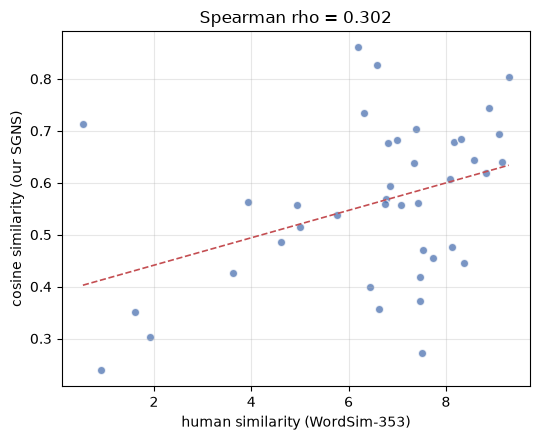

In [21]:
plt.figure(figsize=(5.5, 4.5))
plt.scatter(human, model, alpha=.75, color="#4C72B0", edgecolor="white")
z = np.polyfit(human, model, 1)
xs = np.linspace(min(human), max(human), 50)
plt.plot(xs, np.polyval(z, xs), "--", color="#C44E52", lw=1.2)
plt.xlabel("human similarity (WordSim-353)"); plt.ylabel("cosine similarity (our SGNS)")
plt.title(f"Spearman rho = {rho:.3f}"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [22]:
# --- Probe 3: analogies ---
ANALOGIES = [
    ("man", "woman", "king"),   ("man", "woman", "boy"),
    ("he", "she", "his"),       ("good", "better", "bad"),
    ("day", "days", "year"),    ("go", "went", "take"),
    ("one", "two", "first"),    ("small", "smaller", "large"),
]

hits_at_1 = hits_at_5 = evaluated = 0
for a, b, c in ANALOGIES:
    hits = emb.analogy(a, b, c, 5)
    q = f"{a} : {b} :: {c} : ?"
    if not hits:
        print(f"{q:<34} -- out of vocab: {[w for w in (a,b,c) if w not in vocab]}")
        continue
    evaluated += 1
    print(f"{q:<34} " + ", ".join(f"{w} ({s:.2f})" for w, s in hits))

print(f"\n{evaluated}/{len(ANALOGIES)} analogies had all three query words in vocabulary")

man : woman :: king : ?            sing (0.68), henrietta (0.66), jastrow (0.65), thompson (0.65), szold (0.65)
man : woman :: boy : ?             girl (0.76), baby (0.74), maid (0.71), dancing (0.71), langford (0.70)
he : she :: his : ?                her (0.80), doll (0.58), my (0.58), husband (0.57), smile (0.57)
good : better :: bad : ?           worse (0.71), harder (0.70), stronger (0.66), else (0.65), yours (0.63)
day : days :: year : ?             months (0.73), years (0.73), weeks (0.67), visits (0.63), decades (0.60)
go : went :: take : ?              took (0.68), takes (0.60), taking (0.60), handed (0.56), gave (0.55)
one : two :: first : ?             eleven (0.51), eighteen (0.49), correspondence (0.48), three (0.48), nine (0.48)
small : smaller :: large : ?       larger (0.71), engines (0.66), consonantal (0.65), packages (0.64), dwellings (0.64)

8/8 analogies had all three query words in vocabulary


Read the top-1 predictions and note where the split falls. The **syntactic and morphological**
analogies mostly land: `boy → girl`, `his → her`, `bad → worse`, `year → months/years`,
`large → larger`, `take → took`. The **semantic** one that word2vec is famous for —
`man : woman :: king : ?` — does not, and neither does `one : two :: first : ?`.

That split is the finding, and it follows from counts. Solving an analogy needs the offset $b - a$
to be consistent across many instantiations of the relation. Inflection patterns
(singular/plural, present/past, comparative) recur thousands of times in a million tokens, so their
offsets are well estimated. A specific semantic relation like *male royal → female royal* is
instantiated a handful of times — Brown mentions `king` under a hundred times and `queen` fewer — so
its offset is fitted to noise.

The lesson is not "analogies fail on small corpora" but the sharper one: **each analogy needs its own
relation seen often enough**, and frequency, not the algorithm, decides which ones make it.

In [23]:
# --- Probe 4a: odd one out ---
GROUPS = [
    ["monday", "tuesday", "sunday", "water"],
    ["red", "blue", "green", "school"],
    ["france", "germany", "england", "table"],
    ["one", "two", "three", "house"],
    ["mother", "father", "sister", "money"],
]
for g in GROUPS:
    present = [w for w in g if w in vocab]
    if len(present) < 3:
        print(f"{g} -> too few in vocab ({present})")
    else:
        print(f"{str(present):<56} odd -> {emb.odd_one_out(present)}")

['monday', 'tuesday', 'sunday', 'water']                 odd -> water
['red', 'blue', 'green', 'school']                       odd -> school
['france', 'germany', 'england', 'table']                odd -> table
['one', 'two', 'three', 'house']                         odd -> house
['mother', 'father', 'sister', 'money']                  odd -> money


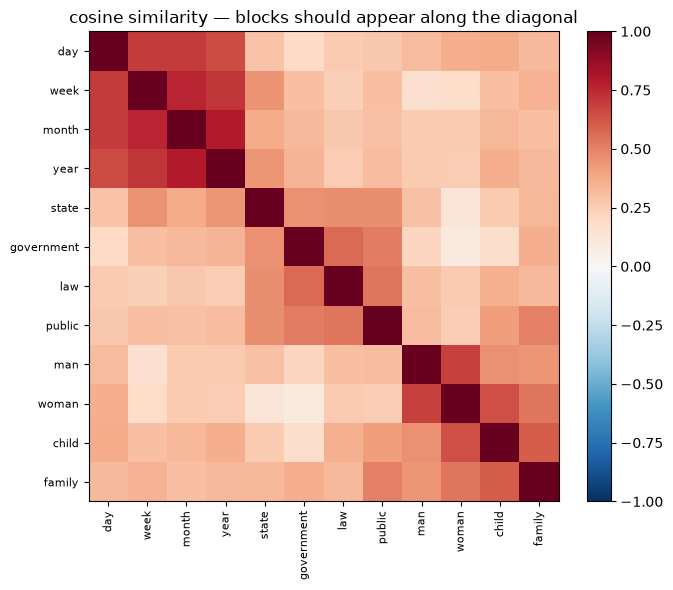

mean within-field similarity : 0.594
mean across-field similarity : 0.296
separation                   : +0.298


In [24]:
# --- Probe 4b: similarity heatmap over three semantic fields ---
FIELDS = {
    "time":    ["day", "week", "month", "year"],
    "society": ["state", "government", "law", "public"],
    "person":  ["man", "woman", "child", "family"],
}
words  = [w for group in FIELDS.values() for w in group if w in vocab]
labels = np.array([f for f, group in FIELDS.items() for w in group if w in vocab])
V = np.stack([emb.vec(w) for w in words])
S = V @ V.T

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(S, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(words)), labels=words, rotation=90, fontsize=8)
ax.set_yticks(range(len(words)), labels=words, fontsize=8)
ax.set_title("cosine similarity — blocks should appear along the diagonal")
plt.colorbar(im, fraction=.046)
plt.tight_layout(); plt.show()

same = (labels[:, None] == labels[None, :]) & ~np.eye(len(labels), dtype=bool)
diff = labels[:, None] != labels[None, :]
print(f"mean within-field similarity : {S[same].mean():.3f}")
print(f"mean across-field similarity : {S[diff].mean():.3f}")
print(f"separation                   : {S[same].mean() - S[diff].mean():+.3f}")

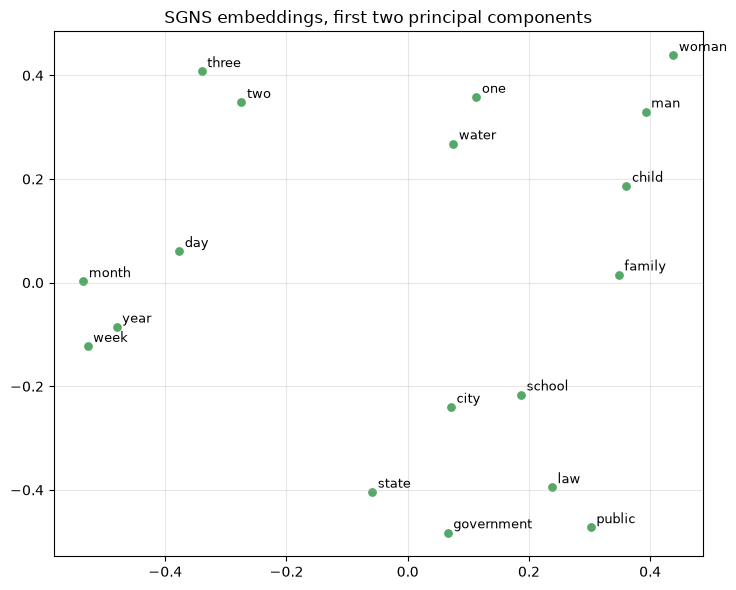

In [25]:
# --- PCA projection of the same words, for a picture of that structure ---
sel = [w for w in ["day","week","month","year","state","government","law","public",
                   "man","woman","child","family","one","two","three","water","city","school"]
       if w in vocab]
X = np.stack([emb.vec(w) for w in sel])
Xc = X - X.mean(0)
_, _, Vt = np.linalg.svd(Xc, full_matrices=False)
P = Xc @ Vt[:2].T

plt.figure(figsize=(7.5, 6))
plt.scatter(P[:, 0], P[:, 1], s=28, color="#55A868")
for (x, y), w in zip(P, sel):
    plt.annotate(w, (x, y), fontsize=9, xytext=(4, 3), textcoords="offset points")
plt.title("SGNS embeddings, first two principal components")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Saving the artefacts

`embeddings.txt` uses the word2vec text format, so these vectors load with
`gensim.KeyedVectors` — and, more to the point, with **Assignment 4**, which pits them against
GloVe on a sentiment task.

In [26]:
def save_word2vec_format(path, emb, cfg):
    with open(path, "w", encoding="utf-8") as fh:
        fh.write(f"{len(emb.vocab)} {cfg.dim}\n")
        for i, w in enumerate(emb.vocab.itos):
            fh.write(w + " " + " ".join(f"{x:.5f}" for x in emb.E[i]) + "\n")

save_word2vec_format(ARTIFACTS / "sgns_embeddings.txt", emb, CFG)
np.savez_compressed(ARTIFACTS / "sgns_model.npz", E=E, U=U,
                    itos=np.array(vocab.itos), counts=vocab.counts)
(ARTIFACTS / "sgns_config.json").write_text(json.dumps(asdict(CFG), indent=2))

for f in ["sgns_embeddings.txt", "sgns_model.npz", "sgns_config.json"]:
    p = ARTIFACTS / f
    print(f"{f:<24} {p.stat().st_size / 1e6:>7.2f} MB")

sgns_embeddings.txt        10.30 MB
sgns_model.npz             18.47 MB
sgns_config.json            0.00 MB


## Discussion

**What worked.** Nearest neighbours are coherent, within-field similarity clearly exceeds
across-field similarity, the WordSim correlation lands around $\rho \approx 0.35$ — well above
chance — and the odd-one-out probe is solved on every group. Morphological and syntactic analogies
resolve correctly. All from ~1 M tokens, hand-derived gradients, and no autograd.

**What did not.** Purely semantic analogies (`man : woman :: king : ?`) fail, for the frequency
reason given in §7. And neighbours are *topical* as much as synonymous: `money → borrow, repay,
unemployment` is a topic, not a synonym set, and antonyms like `hot`/`cold` sit close together
because they occur in the same contexts. The objective cannot distinguish "similar" from "opposite" —
a property of the distributional hypothesis itself, not a bug in the implementation.

**The three design decisions that mattered most**

| Decision | Alternative | Why this one |
|---|---|---|
| Negative sampling, $k = 10$ | full softmax over $M$ | $O(k)$ vs $O(M)$ per pair — three orders of magnitude fewer dot products at $M = 12{,}000$ |
| Subsampling at $t = 10^{-3}$ | keep every token | without it a large share of pairs involve a stopword; content vectors barely train |
| $P_n \propto f^{0.75}$ | uniform, or raw $f$ | uniform never pushes frequent words apart; raw $f$ samples little but `the` |

**Limitations, in order of how much they cost**

1. **Corpus size.** 1 M tokens is two to four orders of magnitude below what these vectors want.
   This is the binding constraint on every number above.
2. **One vector per word type.** `bank` gets a single point that averages river-bank and money-bank.
   Assignment 5 measures exactly this failure and shows what contextual embeddings do about it.
3. **No subword information.** An out-of-vocabulary word has no vector at all — not even a guess.
   FastText's character n-grams fix this; word2vec cannot.
4. **Window-based context only.** Syntax is invisible: `dog bites man` and `man bites dog` yield
   identical training pairs.

**References**

1. Mikolov et al. (2013). *Distributed Representations of Words and Phrases and their
   Compositionality.* NeurIPS. — negative sampling, subsampling, the $0.75$ exponent
2. Mikolov et al. (2013). *Efficient Estimation of Word Representations in Vector Space.* ICLR. —
   Skip-Gram and CBOW, the analogy task
3. Goldberg & Levy (2014). *word2vec Explained.* arXiv:1402.3722. — the §6 derivation, done carefully
4. Levy & Goldberg (2014). *Neural Word Embedding as Implicit Matrix Factorization.* NeurIPS. —
   SGNS is factorising a shifted PMI matrix